In [ ]:
!pip install kaggle

Set Environment Variable

In [ ]:
import json

kaggle_token = {
    "username": "mochamadrafi",
    "key": "KGAT_d00f7cd4de5031d980cf0d96cb43faa9"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_token, f)

In [ ]:
!mkdir -p /root/.kaggle
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

Test Dataset

In [ ]:
!kaggle datasets list -s agriculture

ref                                                                    title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
aman2000jaiswal/agriculture-crop-images                                Agriculture crop images                              62575817  2021-03-10 16:56:50.653000          14122        283  0.9411765        
samuelotiattakorah/agriculture-crop-yield                              Agriculture Crop Yield                               35043399  2024-09-08 02:06:25.477000          11834        104  1.0              
imtkaggleteam/agriculture-dataset-karnataka                            Agriculture dataset | Karnataka                         42206  2024-12-16 09:07:02.877000           3429 

Download Dataset Smart Agriculture

In [ ]:
!kaggle datasets download -d chaitanyagopidesi/smart-agriculture-dataset
!unzip smart-agriculture-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/chaitanyagopidesi/smart-agriculture-dataset
License(s): apache-2.0
  0% 0.00/66.1k [00:00<?, ?B/s]
100% 66.1k/66.1k [00:00<00:00, 170MB/s]
Archive:  smart-agriculture-dataset.zip
  inflating: cropdata_updated.csv    


Load Dataset ke Pandas

In [ ]:
import pandas as pd

df = pd.read_csv("cropdata_updated.csv")
df.head()

,crop ID,soil_type,Seedling Stage,MOI,temp,humidity,result
0,Wheat,Black Soil,Germination,1,25,80.0,1
1,Wheat,Black Soil,Germination,2,26,77.0,1
2,Wheat,Black Soil,Germination,3,27,74.0,1
3,Wheat,Black Soil,Germination,4,28,71.0,1
4,Wheat,Black Soil,Germination,5,29,68.0,1


Data Understanding

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crop ID         16411 non-null  object 
 1   soil_type       16411 non-null  object 
 2   Seedling Stage  16411 non-null  object 
 3   MOI             16411 non-null  int64  
 4   temp            16411 non-null  int64  
 5   humidity        16411 non-null  float64
 6   result          16411 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 897.6+ KB


,0
crop ID,0
soil_type,0
Seedling Stage,0
MOI,0
temp,0
humidity,0
result,0


Data Cleaning

A.Cek Missing Value

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

B. Handle Outliers

In [ ]:
Q1 = df[['Soil_Moisture','Temperature_C','Humidity_Percent']].quantile(0.25)
Q3 = df[['Soil_Moisture','Temperature_C','Humidity_Percent']].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df[['Soil_Moisture','Temperature_C','Humidity_Percent']] < (Q1 - 1.5 * IQR)) |
                (df[['Soil_Moisture','Temperature_C','Humidity_Percent']] > (Q3 + 1.5 * IQR))).any(axis=1)]

df_clean.shape

(16411, 7)

C. Rename Kolom (Standarisasi)

In [ ]:
df.columns

Index(['crop ID', 'soil_type', 'Seedling Stage', 'MOI', 'temp', 'humidity',
       'result'],
      dtype='object')

In [ ]:
df.rename(columns={
    'crop ID': 'Crop_ID',
    'soil_type': 'Soil_Type',
    'Seedling Stage': 'Seedling_Stage',
    'MOI': 'Soil_Moisture',
    'temp': 'Temperature_C',
    'humidity': 'Humidity_Percent',
    'result': 'Crop_Result'
}, inplace=True)

df.columns

Index(['Crop_ID', 'Soil_Type', 'Seedling_Stage', 'Soil_Moisture',
       'Temperature_C', 'Humidity_Percent', 'Crop_Result'],
      dtype='object')

D. Ubah Tipe Data Kategorikal

In [ ]:
df['Soil_Type'] = df['Soil_Type'].astype('category')
df['Seedling_Stage'] = df['Seedling_Stage'].astype('category')
df['Crop_Result'] = df['Crop_Result'].astype('category')

Validasi Struktur Data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16411 entries, 0 to 16410
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Crop_ID           16411 non-null  object  
 1   Soil_Type         16411 non-null  category
 2   Seedling_Stage    16411 non-null  category
 3   Soil_Moisture     16411 non-null  int64   
 4   Temperature_C     16411 non-null  int64   
 5   Humidity_Percent  16411 non-null  float64 
 6   Crop_Result       16411 non-null  category
dtypes: category(3), float64(1), int64(2), object(1)
memory usage: 561.9+ KB


Exploratory Data Analysis

A. Korelasi Variabel Numerik

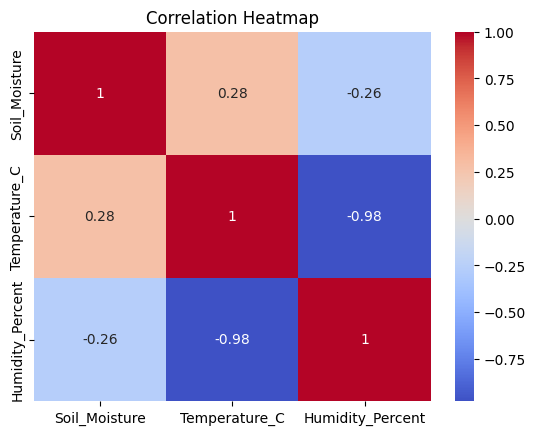

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(
    df_clean[['Soil_Moisture','Temperature_C','Humidity_Percent']].corr(),
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

B. Rata-rata Kondisi per Soil Type

/tmp/ipython-input-3347/2644282941.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_clean.groupby('Soil_Type')[[


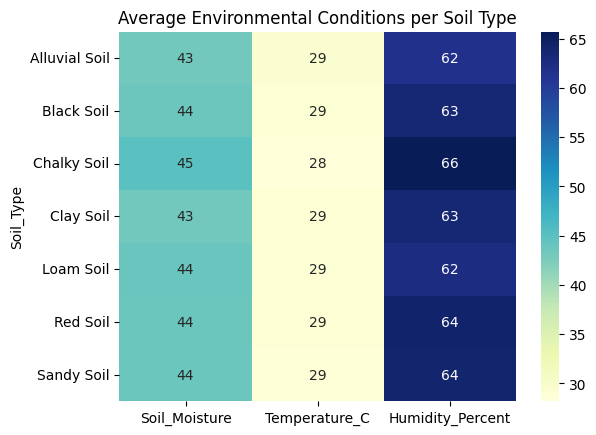

In [ ]:
grouped = df_clean.groupby('Soil_Type')[[
    'Soil_Moisture',
    'Temperature_C',
    'Humidity_Percent'
]].mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()
sns.heatmap(grouped, annot=True, cmap='YlGnBu')
plt.title("Average Environmental Conditions per Soil Type")
plt.show()

C. Distribusi Result

In [ ]:
df['Crop_Result'].value_counts()

,count
Crop_Result,
0,9062
1,6227
2,1122


Simpan Cleaned Data

In [ ]:
df_clean.to_csv("cleaned_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

VISUALIZATION & DASHBOARD

Install Streamlit

In [ ]:
pip install streamlit plotly seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 87.2 MB/s eta 0:00:00


Install Ngrok

In [ ]:
!pip install streamlit pyngrok

Buat File app.py

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# Load Data
# ==============================
df = pd.read_csv("cleaned_data.csv")

st.title("🌾 Smart Agriculture Dashboard")

# Sidebar Filter
soil_option = st.sidebar.selectbox(
    "Select Soil Type",
    df['Soil_Type'].unique()
)

filtered_df = df[df['Soil_Type'] == soil_option]

# ==============================
# 1️⃣ Scatter Plot
# ==============================
st.subheader("Moisture vs Temperature")

fig1 = px.scatter(
    filtered_df,
    x="Soil_Moisture",
    y="Temperature_C",
    color="Crop_Result",
    title="Sensor Relationship"
)
st.plotly_chart(fig1)

# ==============================
# 2️⃣ Gauge Meter (Current Moisture)
# ==============================
st.subheader("Current Soil Moisture Level")

current_moisture = filtered_df['Soil_Moisture'].mean()

fig2 = go.Figure(go.Indicator(
    mode="gauge+number",
    value=current_moisture,
    title={'text': "Average Moisture"},
    gauge={
        'axis': {'range': [0, 100]},
        'bar': {'color': "blue"},
    }
))

st.plotly_chart(fig2)

# ==============================
# 3️⃣ Correlation Heatmap
# ==============================
st.subheader("Sensor Correlation Heatmap")

corr = df[['Soil_Moisture','Temperature_C','Humidity_Percent']].corr()

fig3, ax = plt.subplots()
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
st.pyplot(fig3)

# ==============================
# 4️⃣ Alert System
# ==============================
st.subheader("Moisture Alert System")

threshold = st.slider("Set Moisture Threshold", 0, 100, 30)

if current_moisture < threshold:
    st.error("⚠ WARNING: Soil moisture below threshold!")
else:
    st.success("✅ Moisture level is safe.")

# ==============================
# 5️⃣ Soil Type Comparison
# ==============================
st.subheader("Average Sensor Values per Soil Type")

grouped = df.groupby('Soil_Type')[[
    'Soil_Moisture',
    'Temperature_C',
    'Humidity_Percent'
]].mean().reset_index()

fig5 = px.bar(
    grouped,
    x='Soil_Type',
    y=['Soil_Moisture','Temperature_C','Humidity_Percent'],
    barmode='group',
    title="Average Sensor Metrics"
)

st.plotly_chart(fig5)

Overwriting app.py


Download app.py

In [ ]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>